In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# general description of the content of the data set
data = pd.read_csv('database.csv')
print(data.head())
print(data.describe())
print(data.shape)

print(f"number of rows is {data.shape[0]} \nnumber of columns is {data.shape[1]}")
print(data.columns) 
print(data.info())
## checking for unique features.
def unique(data):
    unique_features = []
    for string in data.columns:
        if len(data[string].unique()) == len(data):
            unique_features.append(string)
    return unique_features

print(unique(data)) # we can see that the only unique feature is earthquakeID.

print(data.loc[:, ["Date" , "Depth Error"]].tail())




         Date      Time  Latitude  Longitude        Type  Depth  Depth Error  \
0  01/02/1965  13:44:18    19.246    145.616  Earthquake  131.6          NaN   
1  01/04/1965  11:29:49     1.863    127.352  Earthquake   80.0          NaN   
2  01/05/1965  18:05:58   -20.579   -173.972  Earthquake   20.0          NaN   
3  01/08/1965  18:49:43   -59.076    -23.557  Earthquake   15.0          NaN   
4  01/09/1965  13:32:50    11.938    126.427  Earthquake   15.0          NaN   

   Depth Seismic Stations  Magnitude Magnitude Type  ...  \
0                     NaN        6.0             MW  ...   
1                     NaN        5.8             MW  ...   
2                     NaN        6.2             MW  ...   
3                     NaN        5.8             MW  ...   
4                     NaN        5.8             MW  ...   

   Magnitude Seismic Stations  Azimuthal Gap  Horizontal Distance  \
0                         NaN            NaN                  NaN   
1                   

In [99]:
#convertion of Date and Time features to a pandas time object
mask = data["Date"].str.contains("T", na=False)
split_dt = data.loc[mask, "Date"].str.split("T", expand=True)

data.loc[mask, "Date"] = split_dt[0].str.replace("-", "/")
data.loc[mask, "Time"] = split_dt[1].str.split(".").str[0]

data.loc[:, "Date"] = data.loc[:, "Date"] + " " + data.loc[:, "Time"]  
data["Date"] = pd.to_datetime(data["Date"] , format='mixed')
print(data.loc[mask, "Date"].dt.day)

data.rename(columns={"Date":"Date and Time"}, inplace=True) 
data.drop(columns={"Time"} , inplace=True)
print(data.columns)
## finding simoltaneous earthquakes
mask = data["Date and Time"].duplicated(False)
print(data.loc[mask , "Date and Time"].head())

print(data.loc[5303:5305, ["Magnitude", "Latitude", "Longitude"]])




#the only completely unique feature is the ID feature.

3378     23
7512     28
20650    13
Name: Date, dtype: int32
Index(['Date and Time', 'Latitude', 'Longitude', 'Type', 'Depth',
       'Depth Error', 'Depth Seismic Stations', 'Magnitude', 'Magnitude Type',
       'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap',
       'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID',
       'Source', 'Location Source', 'Magnitude Source', 'Status'],
      dtype='str')
5303   1979-10-16 06:58:43
5304   1979-10-16 06:58:43
5531   1980-05-25 19:44:51
5532   1980-05-25 19:44:51
5761   1981-01-18 18:11:28
Name: Date and Time, dtype: datetime64[us]
      Magnitude   Latitude  Longitude
5303        5.6  33.020000  -115.5800
5304        5.8  32.998667  -115.5575
5305        5.7  -1.155000   136.4160


In [ ]:
#Dictionary for encoded values.
#In order to understand what country each number represents
sorted_LS = sorted(data["Location Source"].unique())
Dict = {}
i = 0
for a in sorted_LS:
    Dict[a] = i
    i+=1
print(Dict)

#feature engineering
## factorize function . creation of encoded LS column. 
data["Location Source_numeric"] = pd.factorize(data["Location Source"], sort= True)[0]
print(data["Location Source_numeric"].head())





{'AEI': 0, 'AEIC': 1, 'AG': 2, 'AGS': 3, 'AK': 4, 'ATH': 5, 'ATLAS': 6, 'B': 7, 'BEO': 8, 'BOU': 9, 'BRK': 10, 'CAR': 11, 'CASC': 12, 'CI': 13, 'CSEM': 14, 'G': 15, 'GCMT': 16, 'GUC': 17, 'H': 18, 'HVO': 19, 'ISCGEM': 20, 'ISK': 21, 'JMA': 22, 'LIM': 23, 'MDD': 24, 'NC': 25, 'NN': 26, 'OTT': 27, 'PGC': 28, 'PR': 29, 'ROM': 30, 'RSPR': 31, 'SE': 32, 'SJA': 33, 'SLC': 34, 'SPE': 35, 'TAP': 36, 'TEH': 37, 'THE': 38, 'THR': 39, 'TUL': 40, 'U': 41, 'UCR': 42, 'UNM': 43, 'US': 44, 'US_WEL': 45, 'UW': 46, 'WEL': 47}
0    20
1    20
2    20
3    20
4    20
Name: Location Source_numeric, dtype: int64


In [ ]:
#quality and completeness of the Data. checking for missing values.
#maybe looking for a pattern in the missing data.
#can anything be deduced from the data missing.
#how would have i completed the missing data.

missing_data = data.isnull().sum()
print(missing_data)
print(data["Azimuthal Gap"].isnull() == False)
print(data.loc[data["Azimuthal Gap"].isnull() == False, "Azimuthal Gap"])

#i wouldnt have completed any missing data because changing these specific error features 
#is like altering the reality of what happened during that earthquake. 
#in data science as taught columns which are missing more than 40 perecnt of their values are useless for prediction.
#in conlcusion i wouldn't have completed anything, i would have probably erased most of the columns having more than
#40 percent null values






Date and Time                     0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
Location Source_numeric           0
dtype: int64
0        False
1        False
2        False
3        False
4        False
         ...  
23407     True
23408     True
23409     True
23410     True
23411     True
Name: Azimuthal Gap, Length: 23412, dtype: bool
489      335.00
56

In [ ]:
dups = data.duplicated()


print(f"duplicates: {(data[dups])}") #no complete duplicates. what we were expecting to get beacuse each earthquake is distinct from the other

#partial duplicates
dupes = data[data.duplicated(subset=['Date and Time'], keep=False)]
dupes = dupes.sort_values(by=['Date and Time'])
print(f"number of time dupes: {len(dupes)}")

#Date and time is almost unique with respect to the 
#size of the data set 38 duplicates with respect to 20000 rows

#another method
Dt = data["Date and Time"].unique()
print(f"unique out of time: {Dt}")
print("\n")
print(f"number of uniqes: {data.nunique()}")



duplicates: Empty DataFrame
Columns: [Date and Time, Latitude, Longitude, Type, Depth, Depth Error, Depth Seismic Stations, Magnitude, Magnitude Type, Magnitude Error, Magnitude Seismic Stations, Azimuthal Gap, Horizontal Distance, Horizontal Error, Root Mean Square, ID, Source, Location Source, Magnitude Source, Status, Location Source_numeric]
Index: []

[0 rows x 21 columns]
number of time dupes: 38
unique out of time: <DatetimeArray>
['1965-01-02 13:44:18', '1965-01-04 11:29:49', '1965-01-05 18:05:58',
 '1965-01-08 18:49:43', '1965-01-09 13:32:50', '1965-01-10 13:36:32',
 '1965-01-12 13:32:25', '1965-01-15 23:17:42', '1965-01-16 11:32:37',
 '1965-01-17 10:43:17',
 ...
 '2016-12-24 03:58:55', '2016-12-25 14:22:27', '2016-12-25 14:32:13',
 '2016-12-27 23:20:56', '2016-12-28 08:18:01', '2016-12-28 08:22:12',
 '2016-12-28 09:13:47', '2016-12-28 12:38:51', '2016-12-29 22:30:19',
 '2016-12-30 20:08:28']
Length: 23393, dtype: datetime64[us]


number of uniqes: Date and Time               

In [ ]:

# Suspicious Values (Negative Depth)
print(data[data['Depth'] < 0][['Type', 'Depth', 'Magnitude']])
#checking for non_realistic magnitudes
print(data[data['Magnitude'] > 10][['Type', 'Magnitude']])
#checking for times greater than 2016. beacuse the last update was nine years ago
print(data[data['Date and Time'].dt.year > 2016][['Type', 'Depth', 'Magnitude']])


invalid_lat = data[(data['Latitude'] < -90) | (data['Latitude'] > 90)]

invalid_lon = data[(data['Longitude'] < -180) | (data['Longitude'] > 180)]

null_island = data[(data['Latitude'] == 0.0) & (data['Longitude'] == 0.0)]

print(f"Number of rows with impossible Latitude: {len(invalid_lat)}")
print(f"Number of rows with impossible Longitude: {len(invalid_lon)}")
print(f"Number of earthquakes at exact (0.0, 0.0): {len(null_island)}")

             Type  Depth  Magnitude
8099   Earthquake -0.076       5.60
10977  Earthquake -0.097       7.30
10978  Earthquake -1.100       5.77
Empty DataFrame
Columns: [Type, Magnitude]
Index: []
Empty DataFrame
Columns: [Type, Depth, Magnitude]
Index: []
Number of rows with impossible Latitude: 0
Number of rows with impossible Longitude: 0
Number of earthquakes at exact (0.0, 0.0): 0


In [ ]:
import scipy.stats as ss

num_cols = ['Depth', 'Magnitude','Longitude', 'Latitude']


summary = data[num_cols].describe()

# Adding MAD and Skewness
summary.loc['MAD'] = data[num_cols].apply(lambda x: (x - x.median()).abs().median())
summary.loc['IQR'] = summary.loc['75%'] - summary.loc['25%']
summary.loc['Skewness'] = data[num_cols].skew()
display(summary.round(2))


for col in num_cols:
    print(f"\nAnalyzing Outliers for: {col}")
    
    # Method 1: Z-Score (> 3 std)
    z_scores = np.abs(ss.zscore(data[col].dropna()))
    outliers_z = (z_scores > 3).sum()
    
    # Method 2: IQR Method
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers_iqr = ((data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))).sum()
    
    # Method 3: MAD Method (Median Absolute Deviation > 3.5)
    median = data[col].median()
    mad = np.median(np.abs(data[col].dropna() - median))
    outliers_mad = (np.abs(data[col].dropna() - median) / mad > 3.5).sum()
    
    # Method 4: Percentiles (1st and 99th)
    p1 = data[col].quantile(0.01)
    p99 = data[col].quantile(0.99)
    outliers_perc = ((data[col] < p1) | (data[col] > p99)).sum()
    
    # Method 5: Domain-Specific Physical Anomalies (e.g., values < 0)
    outliers_domain = (data[col] < 0).sum()
    
    print(f"Method 1 (Z-Score > 3): {outliers_z} outliers")
    print(f"Method 2 (IQR Method): {outliers_iqr} outliers")
    print(f"Method 3 (MAD Method): {outliers_mad} outliers")
    print(f"Method 4 (Percentiles 1-99): {outliers_perc} outliers")
    print(f"Method 5 (Physical Domain): {outliers_domain} outliers")

,Depth,Magnitude,Longitude,Latitude
count,23412.00,23412.00,23412.00,23412.00
mean,70.77,5.88,39.64,1.68
std,122.65,0.42,125.51,30.11
min,-1.10,5.50,-180.00,-77.08
25%,14.52,5.60,-76.35,-18.65
50%,33.00,5.70,103.98,-3.57
75%,54.00,6.00,145.03,26.19
max,700.00,9.10,180.00,86.00
MAD,19.00,0.20,59.96,18.87
IQR,39.48,0.40,221.38,44.84



Analyzing Outliers for: Depth
Method 1 (Z-Score > 3): 1050 outliers
Method 2 (IQR Method): 3274 outliers
Method 3 (MAD Method): 3740 outliers
Method 4 (Percentiles 1-99): 470 outliers
Method 5 (Physical Domain): 3 outliers

Analyzing Outliers for: Magnitude
Method 1 (Z-Score > 3): 447 outliers
Method 2 (IQR Method): 1475 outliers
Method 3 (MAD Method): 2306 outliers
Method 4 (Percentiles 1-99): 223 outliers
Method 5 (Physical Domain): 0 outliers

Analyzing Outliers for: Longitude
Method 1 (Z-Score > 3): 0 outliers
Method 2 (IQR Method): 0 outliers
Method 3 (MAD Method): 4364 outliers
Method 4 (Percentiles 1-99): 470 outliers
Method 5 (Physical Domain): 8665 outliers

Analyzing Outliers for: Latitude
Method 1 (Z-Score > 3): 0 outliers
Method 2 (IQR Method): 0 outliers
Method 3 (MAD Method): 173 outliers
Method 4 (Percentiles 1-99): 470 outliers
Method 5 (Physical Domain): 12794 outliers


In [ ]:
#categorical analysis
cat_cols = ["Type" , "Magnitude Type" , "Location Source" , "Status"]


for col in cat_cols:
    #distibuiton of each one of the values
    vc = data[col].value_counts()
    vc_pct = data[col].value_counts(normalize=True)*100

    conc = pd.DataFrame({"count" : vc , "Percentagage" : vc_pct})
    display(conc.round(2))

    cum_pct = vc_pct.cumsum()

    if col in ["Type" , "Statues","Location Source"]: K=1 
    else: K=3
    top_k_coverage = cum_pct.iloc[min(K-1, len(cum_pct)-1)]
    print(f"1. Top {K} values cover: {top_k_coverage:.2f}% of the data.") 

    P = 99 if col in ['Type', 'Status' , "Location Source"] else 80
    vals_for_p = cum_pct[cum_pct <= P].index.tolist()

    if not vals_for_p or (len(vals_for_p) < len(cum_pct) and cum_pct[vals_for_p[-1]] < P):
        vals_for_p.append(cum_pct.index[len(vals_for_p)])
        
    print(f"2. Minimum values to cover ~{P}% of data: {len(vals_for_p)} values.")
    print(f"   These values are: {vals_for_p}")





    












,count,Percentagage
Type,,
Earthquake,23232,99.23
Nuclear Explosion,175,0.75
Explosion,4,0.02
Rock Burst,1,0.00


1. Top 1 values cover: 99.23% of the data.
2. Minimum values to cover ~99% of data: 1 values.
   These values are: ['Earthquake']


,count,Percentagage
Magnitude Type,,
MW,7722,32.99
MWC,5669,24.22
MB,3761,16.07
MWB,2458,10.50
MWW,1983,8.47
MS,1702,7.27
ML,77,0.33
MWR,26,0.11
MD,6,0.03


1. Top 3 values cover: 73.27% of the data.
2. Minimum values to cover ~80% of data: 4 values.
   These values are: ['MW', 'MWC', 'MB', 'MWB']


,count,Percentagage
Location Source,,
US,20350,86.92
ISCGEM,2581,11.02
CI,61,0.26
GCMT,56,0.24
NC,54,0.23
GUC,46,0.20
AEIC,40,0.17
UNM,21,0.09
PGC,19,0.08


1. Top 1 values cover: 86.92% of the data.
2. Minimum values to cover ~99% of data: 7 values.
   These values are: ['US', 'ISCGEM', 'CI', 'GCMT', 'NC', 'GUC', 'AEIC']


,count,Percentagage
Status,,
Reviewed,20773,88.73
Automatic,2639,11.27


1. Top 3 values cover: 100.00% of the data.
2. Minimum values to cover ~99% of data: 2 values.
   These values are: ['Reviewed', 'Automatic']


In [ ]:
# 1. Num-Num Correlations
pearson_corr = data[['Latitude', 'Longitude', 'Depth', 'Magnitude']].corr(method='pearson')
spearman_corr = data[['Latitude', 'Longitude', 'Depth', 'Magnitude']].corr(method='spearman')
kendall_corr = data[['Latitude', 'Longitude', 'Depth', 'Magnitude']].corr(method='kendall')

# 2. Cat-Cat Correlation (Cramér's V)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2/n) / min(k-1, r-1))

print(f"Cramer's V (Type vs Status): {cramers_v(data['Type'], data['Status'])}")
print(f"Cramer's V (Magnitude source vs Status): {cramers_v(data['Magnitude Source'], data['Status'])}")
print(f"Cramer's V (Magnitude source vs Location source): {cramers_v(data['Magnitude Source'], data['Location Source'])}")
print(f"Cramer's V (Magnitude Type vs Location source): {cramers_v(data['Magnitude Type'], data['Location Source'])}")
print(f"Cramer's V (Magnitude Type vs Status): {cramers_v(data['Magnitude Type'], data['Status'])}")


Cramer's V (Type vs Status): 0.031373504817563444
Cramer's V (Magnitude source vs Status): 0.9884356527887218
Cramer's V (Magnitude source vs Location source): 0.6168489532241836
Cramer's V (Magnitude Type vs Location source): 0.4631976748700822
Cramer's V (Magnitude Type vs Status): 0.4920641590077101


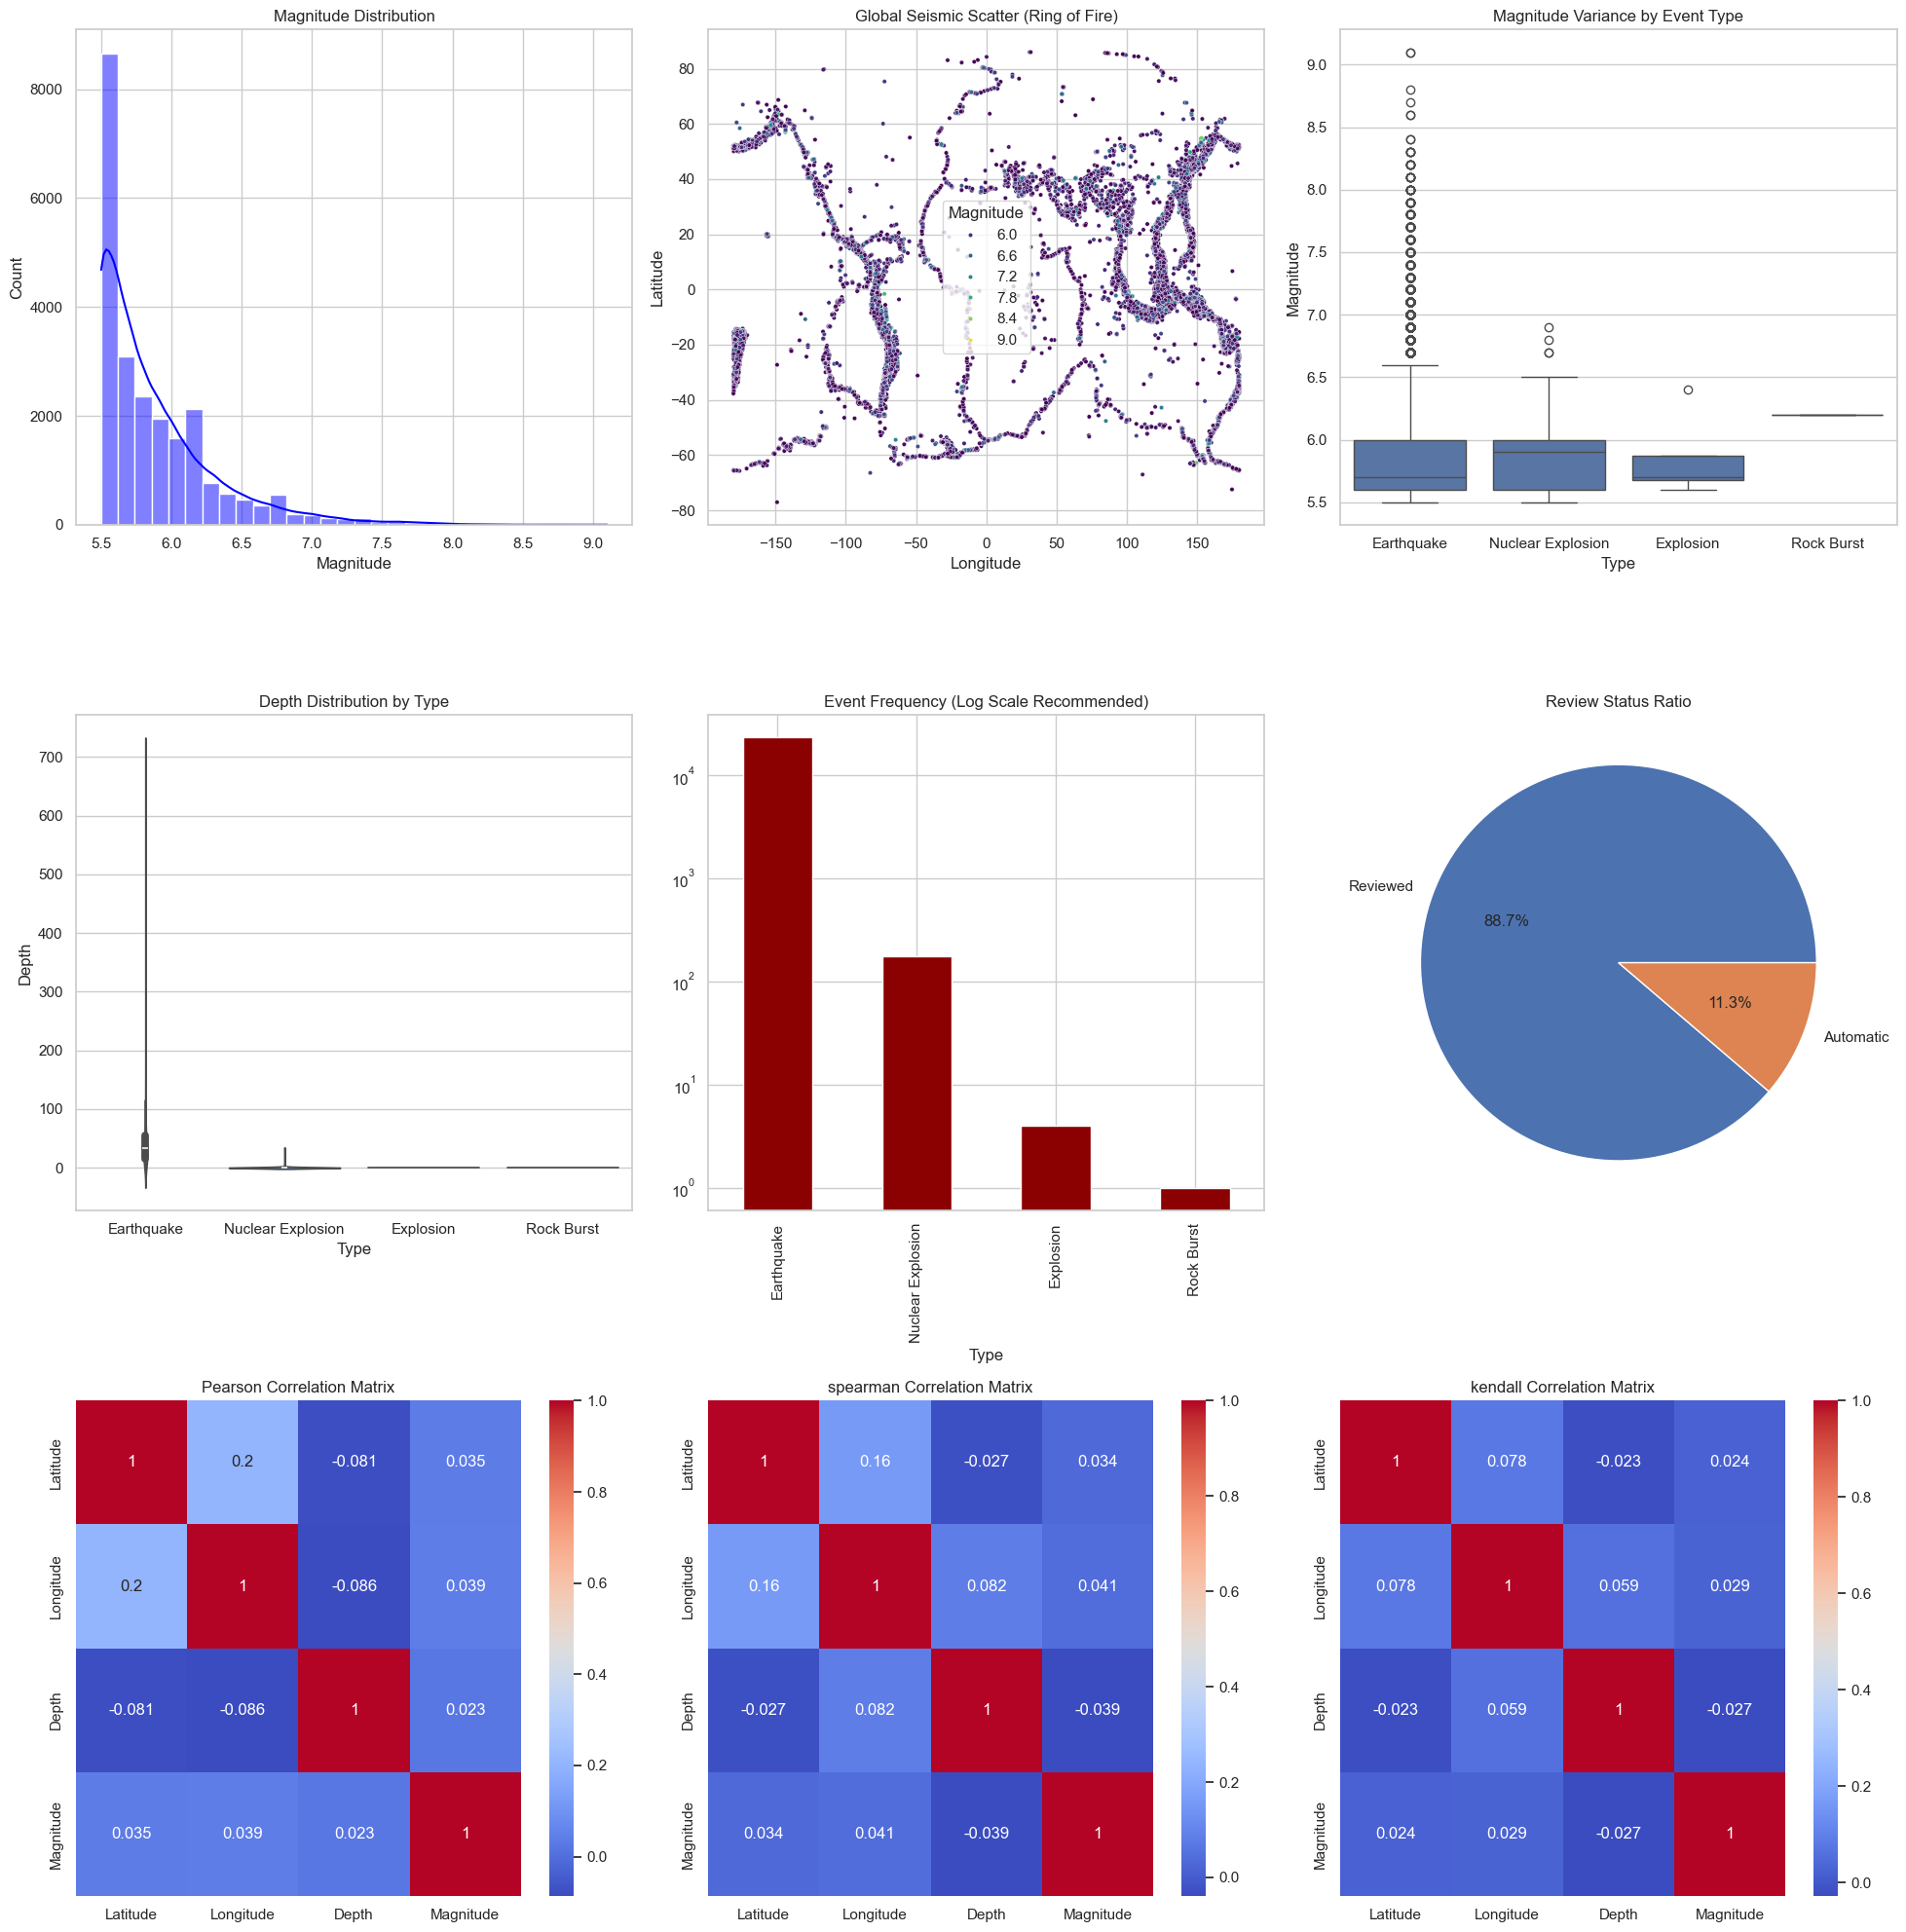

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(20, 20))

# 1. Histogram
sns.histplot(data['Magnitude'], bins=30, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Magnitude Distribution')

# 2. Scatterplot
sns.scatterplot(x='Longitude', y='Latitude', hue='Magnitude', data=data, ax=axes[0, 1], palette='viridis', s=10)
axes[0, 1].set_title('Global Seismic Scatter (Ring of Fire)')

# 3. Boxplot
sns.boxplot(x='Type', y='Magnitude', data=data, ax=axes[0, 2])
axes[0, 2].set_title('Magnitude Variance by Event Type')

# 4. Violin Plot
sns.violinplot(x='Type', y='Depth', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Depth Distribution by Type')

# 5. Bar Chart
data['Type'].value_counts().plot(kind='bar', ax=axes[1, 1], color='darkred')
axes[1, 1].set_title('Event Frequency (Log Scale Recommended)')
axes[1, 1].set_yscale('log')

# 6. Pie Chart
data['Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1, 2])
axes[1, 2].set_title('Review Status Ratio')

# 7. Heatmap
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', ax=axes[2, 0])
axes[2, 0].set_title('Pearson Correlation Matrix')

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', ax=axes[2, 1])
axes[2, 1].set_title('spearman Correlation Matrix')

sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', ax=axes[2, 2])
axes[2, 2].set_title('kendall Correlation Matrix')


plt.tight_layout()
plt.show()

True


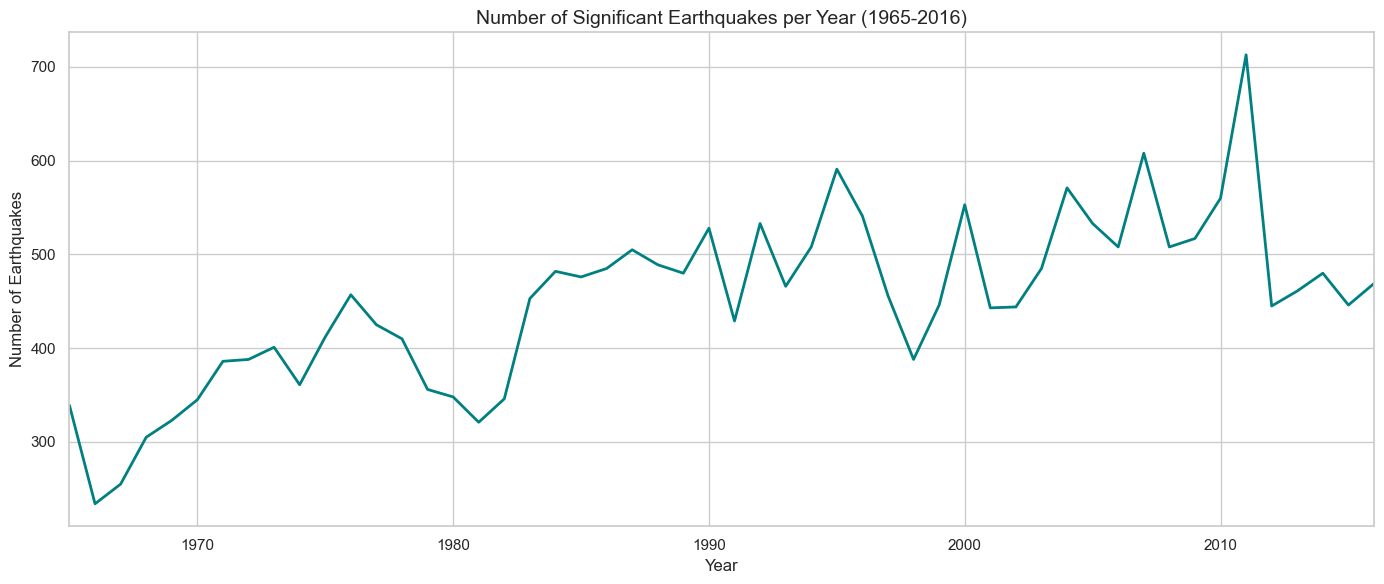

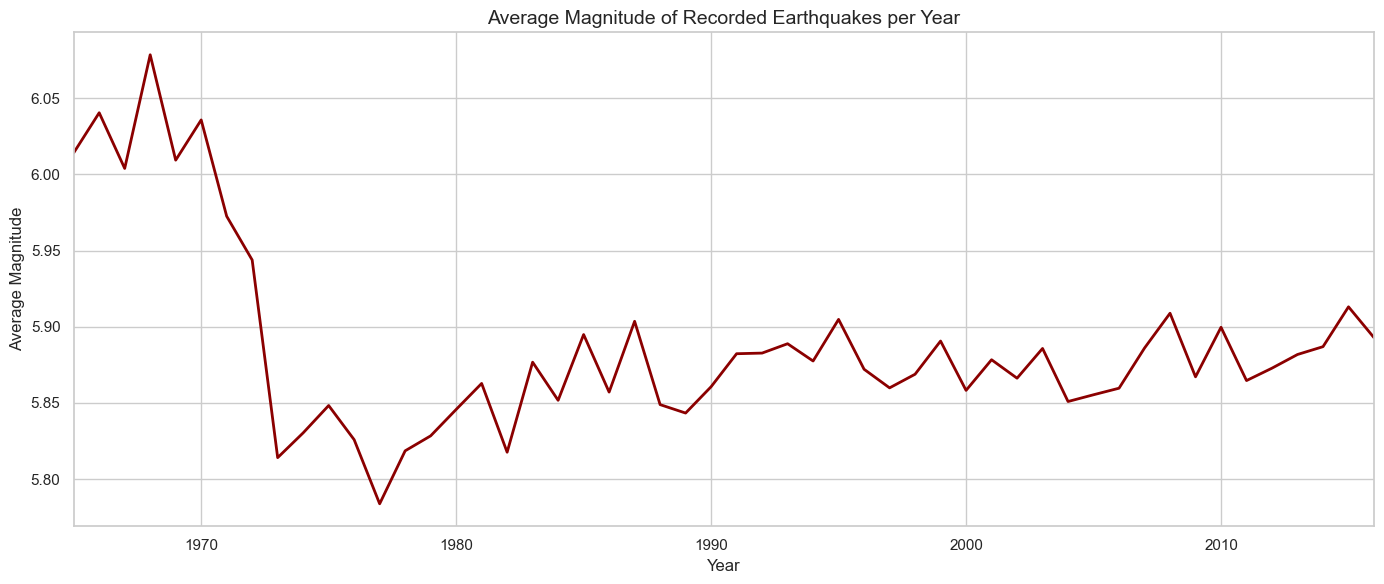

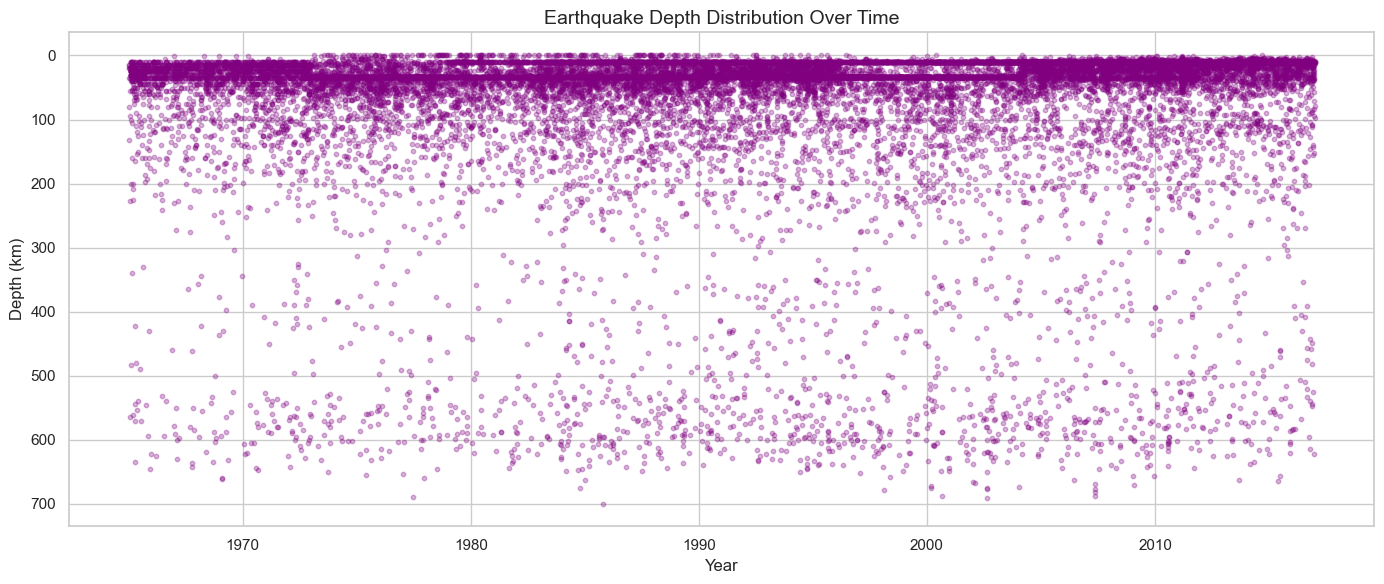

In [ ]:

#does the data change in over time

is_sorted = data["Date and Time"].index.is_monotonic_increasing
#date and time is monotinicly increasing
print(is_sorted)

sns.set_theme(style="whitegrid")\

df_time_indexed = data.set_index('Date and Time', inplace=True)
# Graph 1: Earthquake Frequency Over Time
plt.figure(figsize=(14, 6))
# Resample by Year ('YE') and count occurrences
data['ID'].resample('YE').count().plot(color='teal', linewidth=2)
plt.title('Number of Significant Earthquakes per Year (1965-2016)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Earthquakes', fontsize=12)
plt.tight_layout()
plt.show()

# Graph 2: Average Magnitude Over Time
plt.figure(figsize=(14, 6))
# Resample by Year ('YE') and calculate the mean of the Magnitude
data['Magnitude'].resample('YE').mean().plot(color='darkred', linewidth=2)
plt.title('Average Magnitude of Recorded Earthquakes per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Magnitude', fontsize=12)
plt.tight_layout()
plt.show()

# Graph 3: Depth Over Time (Scatter plot to see distribution changes)
plt.figure(figsize=(14, 6))
plt.scatter(data.index, data['Depth'], alpha=0.3, color='purple', s=10)
plt.title('Earthquake Depth Distribution Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Depth (km)', fontsize=12)
plt.gca().invert_yaxis() # Invert Y-axis so deeper earthquakes are visually lower
plt.tight_layout()
plt.show()